# Final Conclusions

1. Target variables for trip duration prediction were successfully created.

2. Duplicate observations were removed.

3. Missing values were identified for further treatment.

4. Invalid records with unrealistic durations, fares, distances, and passenger counts were excluded.

5. Extreme outliers were removed to improve model robustness.

6. Features likely to introduce data leakage were identified and removed.

7. The cleaned dataset is now suitable for feature engineering and model development.

---

## Next Steps

The next notebook will focus on:

- Temporal feature engineering
- Spatial feature engineering
- Feature transformations
- Preparing modeling datasets

---

# Data Cleaning and Target Variable Creation

## Objective

The objective of this notebook is to prepare the January 2026 NYC Yellow Taxi dataset for predictive modeling.

The following tasks will be performed:

- Create target variables for trip duration and fare prediction.
- Identify and remove invalid observations.
- Handle missing values.
- Remove duplicate records.
- Detect and treat outliers.
- Eliminate features that may introduce data leakage.
- Generate a cleaned dataset for feature engineering and model development.

The quality of the dataset directly influences model performance. Therefore, rigorous data validation and cleaning procedures are essential before proceeding to feature engineering.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE2_Trip_Fare_Forecasting/data/yellow_tripdata_2026-01.parquet"
)

print(df.shape)

(3724889, 20)


# Section 4: Create Target Variables
1. Trip Duration
Why?

For duration prediction, we need the actual duration.

In [3]:
df["trip_duration"] = (
    df["tpep_dropoff_datetime"]
    -
    df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

In [4]:
df["trip_duration"].describe()

count    3.724889e+06
mean     1.719316e+01
std      2.517802e+01
min     -1.170000e+01
25%      8.066667e+00
50%      1.336667e+01
75%      2.120000e+01
max      7.507900e+03
Name: trip_duration, dtype: float64

### Trip Duration Creation

Trip duration was calculated as the difference between dropoff and pickup timestamps.

The resulting duration is expressed in minutes and will serve as the target variable for the trip duration prediction model.

In [5]:
duplicates = df.duplicated().sum()

print(
    f"Duplicate rows: {duplicates:,}"
)

Duplicate rows: 0


# Missing Value Analysis

In [6]:
missing = (
    df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing[
    missing > 0
]

passenger_count         1088058
Airport_fee             1088058
congestion_surcharge    1088058
store_and_fwd_flag      1088058
RatecodeID              1088058
dtype: int64

In [7]:
df["passenger_count"] = (
    df["passenger_count"]
    .fillna(
        df["passenger_count"].mode()[0]
    )
)

 ## Why Impute Passenger_Count
 "passenger_count had approximately 29% missing values. Since it is a relevant pre-trip feature and dropping those observations would significantly reduce the dataset size, I retained the feature and imputed missing values using the mode. Mode imputation was chosen because passenger count is a discrete count variable, and the most frequently occurring value preserves realistic passenger distributions."

In [8]:
df = df[
    df["trip_duration"] > 0
]

#  Remove Upper Bound
df = df[
    df["trip_duration"] <= 180
]

### Trip Duration Validation

Trips with non-positive durations were removed because they represent invalid records.

Trips exceeding 180 minutes were also excluded to reduce the influence of extreme outliers and data entry errors.

In [ ]:
# Remove Invalid Fare
df = df[
    df["fare_amount"] > 0
]

#  Remove Extreme Outliers
df = df[
    df["fare_amount"] <= 200
]

### Fare Validation

Trips with non-positive fare amounts were removed.

Extreme fare values above $200 were excluded to reduce the impact of outliers that could negatively affect model training.

In [9]:
# Distance Cleaning
df = df[
    df["trip_distance"] > 0
]

# Upper Bound
df = df[
    df["trip_distance"] <= 100
]

### Distance Validation

Trips with non-positive distances were removed.

Extremely long trips exceeding 100 miles were excluded as they likely represent anomalies.

In [10]:
df = df[
    df["passenger_count"] >= 1
]

df = df[
    df["passenger_count"] <= 6
]

### Passenger Count Validation

Trips with unrealistic passenger counts were removed.

Valid passenger counts were restricted to values between 1 and 6.

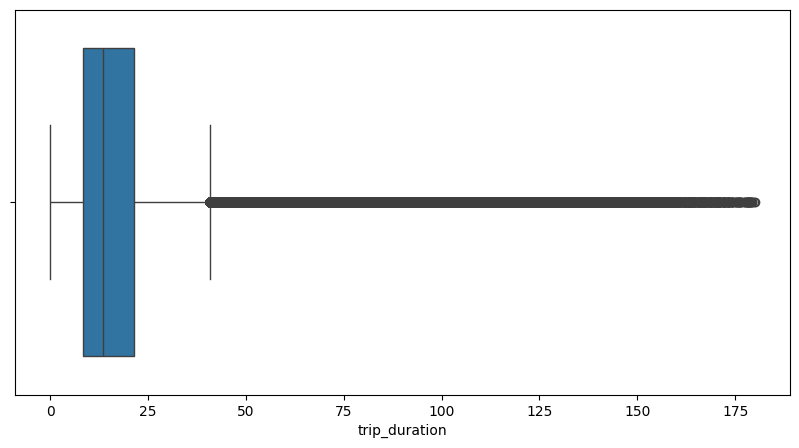

In [11]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["trip_duration"]
)

plt.show()

### Observation: Trip Duration

The majority of taxi trips have durations below 30 minutes, indicating that most rides are relatively short. However, several observations extend beyond the upper whisker, suggesting the presence of extreme trip durations. These may represent unusually long trips, traffic-related delays, or potential data anomalies.

To minimize the influence of extreme values on model performance, trips exceeding 180 minutes were excluded during the data cleaning process.

## Outlier Visualization

For understanding before removal.

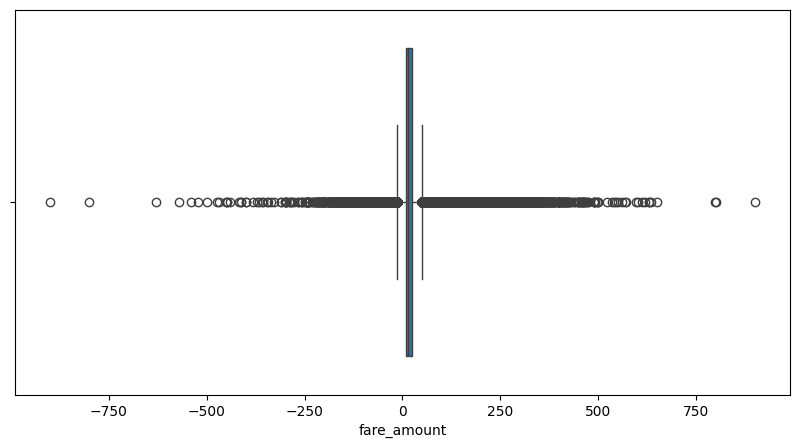

In [12]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["fare_amount"]
)

plt.show()

### Observation: Fare Amount

The fare distribution is highly right-skewed, with most trips having relatively low fare values. The presence of negative fare amounts suggests cancellations, refunds, or data entry errors. Additionally, several extremely high fare values were identified as potential outliers.

To ensure robust model training, trips with non-positive fares were removed, and fares exceeding $200 were treated as extreme outliers and excluded from further analysis.

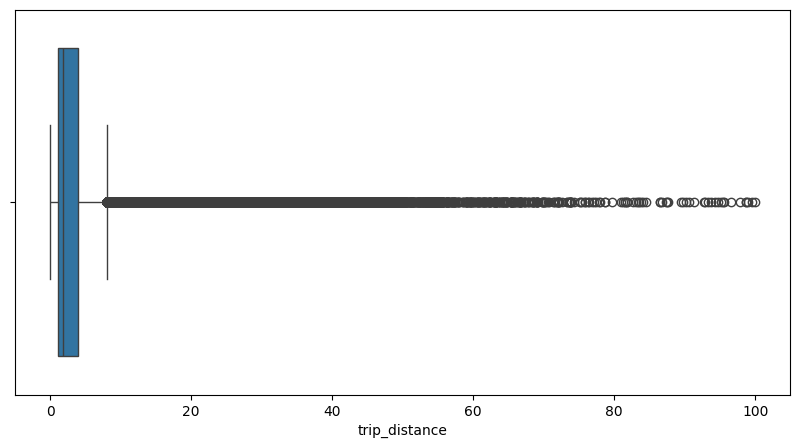

In [13]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["trip_distance"]
)

plt.show()

### Observation: Trip Distance

The majority of taxi trips cover short distances, with most observations concentrated within a few miles. The distribution exhibits a strong positive skew, indicating the presence of a small number of exceptionally long trips.

Trips with non-positive distances were removed, and distances exceeding 100 miles were considered potential anomalies and excluded from the dataset to improve model reliability.

## Leakage Feature Removal

In [14]:
drop_cols = [

    "VendorID",

    "store_and_fwd_flag",

    "payment_type",

    "tip_amount",

    "tolls_amount",

    "total_amount",

    "extra",

    "mta_tax",

    "improvement_surcharge",

    "congestion_surcharge",

    "Airport_fee"

]

In [15]:
# Drop Leakage Features
existing_cols = [
    col for col in drop_cols
    if col in df.columns
]

df.drop(
    columns=existing_cols,
    inplace=True
)

In [16]:
print(df.shape)

df.info()

df.head()

(3539267, 10)
<class 'pandas.core.frame.DataFrame'>
Index: 3539267 entries, 0 to 3724888
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   RatecodeID             float64       
 5   PULocationID           int32         
 6   DOLocationID           int32         
 7   fare_amount            float64       
 8   cbd_congestion_fee     float64       
 9   trip_duration          float64       
dtypes: datetime64[us](2), float64(6), int32(2)
memory usage: 270.0 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,fare_amount,cbd_congestion_fee,trip_duration
0,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,239,238,7.2,0.00,5.550000
3,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,142,209,38.7,0.75,42.800000
5,2026-01-01 00:47:11,2026-01-01 01:00:47,2.0,2.33,1.0,144,137,14.2,0.75,13.600000
6,2026-01-01 00:17:54,2026-01-01 00:28:32,1.0,1.30,1.0,142,50,11.4,0.75,10.633333
8,2026-01-01 00:34:14,2026-01-01 01:11:58,1.0,5.34,1.0,161,45,37.3,0.75,37.733333


In [17]:
print("Initial shape:", df.shape)

# Duration cleaning
df = df[df["trip_duration"] > 0]
print("After removing invalid duration:", df.shape)

df = df[df["trip_duration"] <= 180]
print("After duration outliers:", df.shape)

# Fare cleaning
df = df[df["fare_amount"] > 0]
print("After invalid fares:", df.shape)

df = df[df["fare_amount"] <= 200]
print("After fare outliers:", df.shape)

# Distance cleaning
df = df[df["trip_distance"] > 0]
print("After invalid distance:", df.shape)

df = df[df["trip_distance"] <= 100]
print("After distance outliers:", df.shape)

# Passenger count
df = df[
    (df["passenger_count"] >= 1) &
    (df["passenger_count"] <= 6)
]
print("After passenger count cleaning:", df.shape)

Initial shape: (3539267, 10)
After removing invalid duration: (3539267, 10)
After duration outliers: (3539267, 10)
After invalid fares: (3501024, 10)
After fare outliers: (3499962, 10)
After invalid distance: (3499962, 10)
After distance outliers: (3499962, 10)
After passenger count cleaning: (3499962, 10)


In [19]:
df.to_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE2_Trip_Fare_Forecasting/data/cleaned_taxi_data.parquet",
    index=False
)
print("Clean Dataset Saved")

Clean Dataset Saved
